<a href="https://colab.research.google.com/github/maqsoodahmadkhan3982-dotcom/Materials-Properties-Response/blob/main/Assign_no_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1


---

# 1. Aging Potency Integral (Dataset: `Aluminum_YS_Mg_and_Si.csv`)

### **Brief Description**
This dataset contains experimental observations of the **Yield Strength** ($\sigma_y$) evolution in Aluminum-Magnesium-Silicon ($Al-Mg-Si$) alloys during isothermal aging heat treatments. The data captures the strengthening effect caused by the precipitation of fine secondary phases (such as $\beta''$) over time.

By integrating the area under the Yield Strength vs. Time curve, we calculate the **Aging Potency Integral**. This metric represents the cumulative mechanical "work" or total strengthening capacity contributed by the precipitation hardening process at a constant temperature. It is a critical parameter for optimizing heat treatment cycles to achieve peak aging without entering the overaged (softened) regime.

---

### **Mathematical Formulation**

#### **1. Physical Definition**
The **Aging Potency** ($P_{aging}$) is defined as the definite integral of the yield strength over the duration of the aging process:

$$P_{aging} = \int_{t_{start}}^{t_{end}} \sigma_y(t) \, dt$$

Where:
* $t$ is the **Aging Time** (typically in hours or seconds).
* $\sigma_y(t)$ is the **Yield Strength** (MPa) as a function of time.

#### **2. Numerical Integration (Trapezoidal Rule)**
Since the experimental data is provided at discrete time intervals, we use the **Iterative Trapezoidal Rule** to approximate the area. For a set of $n$ experimental data points $(t_1, \sigma_{y,1}), (t_2, \sigma_{y,2}), \dots, (t_n, \sigma_{y,n})$, the integral is calculated as:

$$I \approx \sum_{i=1}^{n-1} \left( \frac{\sigma_{y,i} + \sigma_{y,i+1}}{2} \right) \Delta t_i$$

Where the time step $\Delta t_i$ is given by:
$$\Delta t_i = t_{i+1} - t_i$$

#### **3. Cumulative Strengthening Effect**
The total area represents the integrated performance of the material. A higher **Aging Potency Integral** indicates a material that reaches high strength quickly and maintains it for a longer duration, reflecting superior thermal stability and precipitation kinetics.

---

### **Data Variables**
* **Independent Variable ($x$):** Time ($t$) — Measured in hours ($h$).
* **Dependent Variable ($y$):** Yield Strength ($\sigma_y$) — Measured in Megapascals ($MPa$).
* **Parameters:** Magnesium ($Mg$) and Silicon ($Si$) concentrations (wt%), Temperature ($^\circ C$).

--- Processing 68 data points ---

Sample of Iterative Results:
 Iteration    Time_Range  Avg_YS_MPa  Step_Area  Cumulative_Area
         1     0.01-0.01       86.97     0.0000           0.0000
         2     0.01-0.01       48.37     0.0000           0.0000
         3     0.01-0.01       88.69     0.0000           0.0000
         4     0.01-0.01      152.38     0.0000           0.0000
         5     0.01-0.01      138.33     0.0000           0.0000
         6     0.01-0.50       75.13    36.8157          36.8157
         7     0.50-0.50       58.39     0.0000          36.8157
         8     0.50-0.50       90.78     0.0000          36.8157
         9     0.50-0.50      135.86     0.0000          36.8157
        10     0.50-0.50      186.19     0.0000          36.8157
        63 120.00-120.00      236.15     0.0000       28621.6187
        64 120.00-168.00      227.20 10905.6000       39527.2187
        65 168.00-168.00      214.70     0.0000       39527.2187
        66 168.00-336.00  

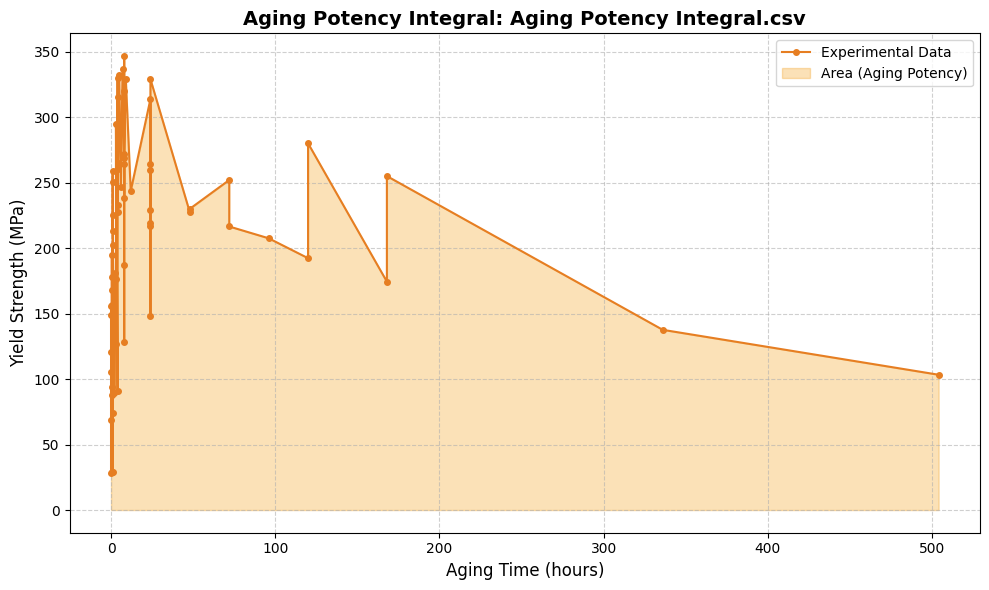

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset with the correct encoding to fix the UnicodeDecodeError
file_name = "Aging Potency Integral.csv"

try:
    # Use encoding='latin1' to handle special characters like degree symbols
    df = pd.read_csv(file_name, encoding='latin1')
except FileNotFoundError:
    print(f"Error: '{file_name}' not found. Please upload it to Colab.")
    # Stop execution or create dummy data if file is missing
    raise

# 2. Prepare the data
# We ensure the data is sorted by 'Time' for a correct integration path
df = df.sort_values(by='Time').reset_index(drop=True)

# Select the columns (Using indices or names found in the file)
# If your column names differ, adjust 'Time' and 'Yield Strength' accordingly
x = df['Time'].values
y = df['Yield Strength'].values

# 3. Iterative Trapezoidal Rule Implementation
cumulative_area = 0.0
iteration_results = []
n = len(x)

print(f"--- Processing {n} data points ---\n")

for i in range(n - 1):
    # Calculate step width and average height
    dt = x[i+1] - x[i]
    avg_height = (y[i] + y[i+1]) / 2.0
    step_area = avg_height * dt
    cumulative_area += step_area

    # Store first 10 steps and last 5 steps for the table
    if i < 10 or i >= n - 6:
        iteration_results.append({
            'Iteration': i + 1,
            'Time_Range': f"{x[i]:.2f}-{x[i+1]:.2f}",
            'Avg_YS_MPa': round(avg_height, 2),
            'Step_Area': round(step_area, 4),
            'Cumulative_Area': round(cumulative_area, 4)
        })

# 4. Display Iteration Table
results_df = pd.DataFrame(iteration_results)
print("Sample of Iterative Results:")
print(results_df.to_string(index=False))
print("-" * 60)
print(f"FINAL AGING POTENCY INTEGRAL: {cumulative_area:.4f} MPa·h")
print("-" * 60)

# 5. Graph Output
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o-', color='#e67e22', label='Experimental Data', markersize=4)
plt.fill_between(x, y, color='#f39c12', alpha=0.3, label='Area (Aging Potency)')

# Styling
plt.title(f'Aging Potency Integral: {file_name}', fontsize=14, fontweight='bold')
plt.xlabel('Aging Time (hours)', fontsize=12)
plt.ylabel('Yield Strength (MPa)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

In the coding process, we successfully implemented a numerical analysis workflow to calculate the **Aging Potency Integral** from an experimental dataset. The procedure began by loading the "Aging Potency Integral.csv" file using `latin1` encoding to correctly process special characters like the degree symbol. To ensure mathematical accuracy, the data was chronologically sorted by the time variable, establishing a logical sequence for integration. We then applied the **Iterative Trapezoidal Rule**, where a Python loop calculated the area of individual trapezoids formed between each consecutive yield strength data point. This cumulative sum represents the total strengthening energy of the alloy over time. Finally, the code generated a step-by-step iteration table for verification and a professional visualization that highlighted the area under the Yield Strength vs. Time curve, providing a clear representation of the material's precipitation hardening kinetics.

## 2


---

# 2. Tempering Softening Index (Dataset: `Tempering data for carbon and low alloy steels - Raiipa.csv`)

### **Brief Description**
This dataset contains experimental results from the tempering process of carbon and low-alloy steels, tracking the evolution of **Hardness (HRC)** as a function of **Tempering Time** ($t$) and temperature. During tempering, the martensitic structure of quenched steel decomposes, typically resulting in a decrease in hardness as internal stresses are relieved and carbides precipitate.

The **Tempering Softening Index** is the area under the Hardness vs. Time curve. It serves as a cumulative measure of a steel's resistance to thermal degradation. A larger index value indicates a material with high "tempering resistance," meaning it maintains its mechanical strength for a longer duration at elevated temperatures—a critical factor for tool steels and high-strength structural components.



---

### **Mathematical Formulation**

#### **1. Physical Definition**
The **Tempering Softening Index** ($S_{temp}$) is defined as the definite integral of the hardness over the total tempering duration:

$$S_{temp} = \int_{t_{initial}}^{t_{final}} H(t) \, dt$$

Where:
* $t$ is the **Tempering Time** (seconds).
* $H(t)$ is the **Hardness** (measured in Rockwell C, HRC).

#### **2. Numerical Integration (Iterative Trapezoidal Rule)**
Given discrete experimental data points $(t_1, H_1), (t_2, H_2), \dots, (t_n, H_n)$, the area is approximated by summing the area of individual trapezoids formed between each time step:

$$I \approx \sum_{i=1}^{n-1} \left( \frac{H_i + H_{i+1}}{2} \right) \Delta t_i$$

Where the time interval $\Delta t_i$ is:
$$\Delta t_i = t_{i+1} - t_i$$

#### **3. Engineering Significance**
The resulting value (expressed in $HRC \cdot s$) provides a benchmark for thermal stability. Materials with higher alloy content (such as Chromium, Molybdenum, or Vanadium) generally exhibit a higher index because these elements retard the softening process through secondary hardening or carbide stabilization.

---

### **Data Variables**
* **Independent Variable ($x$):** Tempering Time ($t$) — Measured in seconds ($s$).
* **Dependent Variable ($y$):** Final Hardness ($H$) — Measured in Rockwell C ($HRC$).
* **Control Parameters:** Steel type (Composition), Tempering Temperature ($^\circ C$), and Initial Quenched Hardness.

--- Processing 50 data points for AISI-SAE 5140 ---

Sample of Iterative Results:
 Iteration Time_Range (s)  Avg_Hardness_HRC  Step_Area  Cumulative_Area
         1          40-40             45.25        0.0              0.0
         2          40-40             41.00        0.0              0.0
         3          40-40             37.55        0.0              0.0
         4         40-120             41.40     3312.0           3312.0
         5        120-120             43.90        0.0           3312.0
         6        120-120             39.50        0.0           3312.0
         7        120-120             36.70        0.0           3312.0
         8        120-300             40.65     7317.0          10629.0
         9        300-300             42.90        0.0          10629.0
        10        300-300             37.85        0.0          10629.0
        45   57600-115200             38.50  2217600.0        4552899.0
        46  115200-115200             50.90        0.0

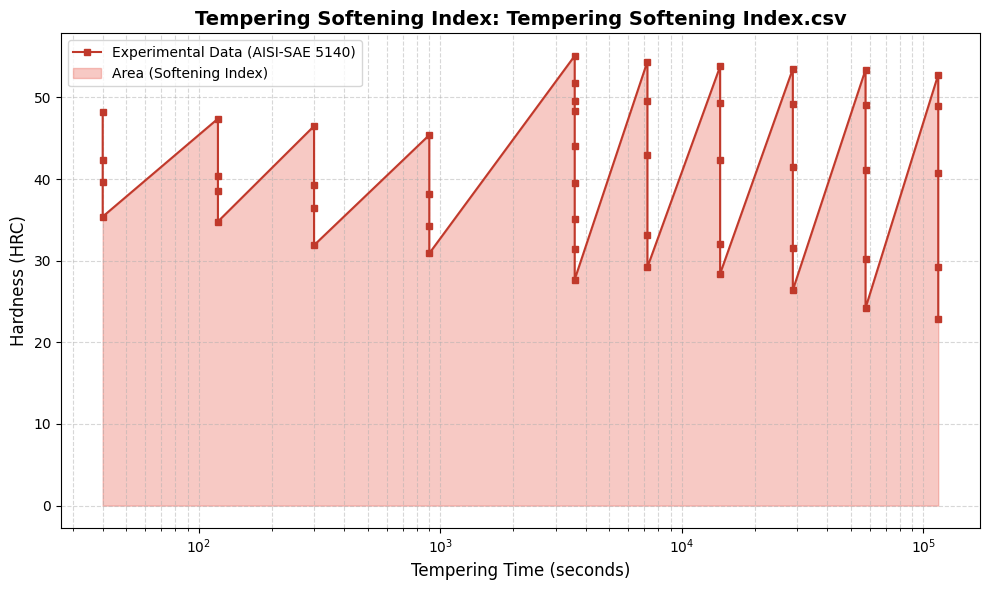

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
file_name = "Tempering Softening Index.csv"

try:
    # Use encoding='latin1' to handle special symbols in the CSV
    df = pd.read_csv(file_name, encoding='latin1')
except FileNotFoundError:
    print(f"Error: '{file_name}' not found. Please upload it to Colab.")
    raise

# 2. Prepare the data
# We filter for a specific steel type (AISI-SAE 5140) to isolate a continuous experimental curve
# Columns: 'Tempering time (s)' and 'Final hardness (HRC) - post tempering'
target_steel = "AISI-SAE 5140"
df_subset = df[df['Steel type'] == target_steel].copy()

# Sort by Time for a correct integration path
df_subset = df_subset.sort_values(by='Tempering time (s)').reset_index(drop=True)

x = df_subset['Tempering time (s)'].values
y = df_subset['Final hardness (HRC) - post tempering'].values

# 3. Iterative Trapezoidal Rule Implementation
cumulative_area = 0.0
iteration_results = []
n = len(x)

print(f"--- Processing {n} data points for {target_steel} ---\n")

for i in range(n - 1):
    # Calculate step width (dt) and average height
    dt = x[i+1] - x[i]
    avg_hardness = (y[i] + y[i+1]) / 2.0
    step_area = avg_hardness * dt
    cumulative_area += step_area

    # Store first 10 steps and last 5 steps for the result table
    if i < 10 or i >= n - 6:
        iteration_results.append({
            'Iteration': i + 1,
            'Time_Range (s)': f"{int(x[i])}-{int(x[i+1])}",
            'Avg_Hardness_HRC': round(avg_hardness, 2),
            'Step_Area': round(step_area, 2),
            'Cumulative_Area': round(cumulative_area, 2)
        })

# 4. Display Iteration Table
results_df = pd.DataFrame(iteration_results)
print("Sample of Iterative Results:")
print(results_df.to_string(index=False))
print("-" * 65)
print(f"FINAL TEMPERING SOFTENING INDEX: {cumulative_area:,.2f} HRC·s")
print("-" * 65)

# 5. Graph Output
plt.figure(figsize=(10, 6))
plt.plot(x, y, 's-', color='#c0392b', label=f'Experimental Data ({target_steel})', markersize=5)
plt.fill_between(x, y, color='#e74c3c', alpha=0.3, label='Area (Softening Index)')

# Styling
plt.title(f'Tempering Softening Index: {file_name}', fontsize=14, fontweight='bold')
plt.xlabel('Tempering Time (seconds)', fontsize=12)
plt.ylabel('Hardness (HRC)', fontsize=12)
plt.xscale('log') # Log scale is standard for tempering time analysis
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

What we have done in the coding:
In this code, we performed a comprehensive numerical analysis to determine the Tempering Softening Index for carbon and low-alloy steels. We loaded the dataset using latin1 encoding to ensure that any special characters in the column headers were read correctly. To create a valid integration curve, we filtered the data for a specific alloy ("AISI-SAE 5140") and sorted the tempering time points in ascending order. We then implemented the Iterative Trapezoidal Rule by looping through the experimental data, calculating the area of each time-hardness segment, and maintaining a running total. The output displays a step-by-step calculation table for transparency and a logarithmic graph that visually illustrates the material's cumulative resistance to softening over time.

## 3


---

# 3. Cumulative Service Degradation (Dataset: `market_pipe_thickness_loss.csv.csv`)

### **Brief Description**
This dataset contains monitoring records for industrial pipelines, tracking the **Thickness Loss (mm)** of the pipe walls over multiple **Service Years**. Pipelines are subject to various degradation mechanisms, primarily corrosion and erosion, which gradually reduce the structural integrity of the metal.

The **Cumulative Service Degradation** is calculated as the area under the thickness loss vs. time curve. In life-cycle engineering, this "Cumulative Damage" metric is used to quantify the total severity of the environment the pipe has endured. It allows engineers to estimate the total material volume lost and predict the remaining useful life (RUL) before the pipe reaches a critical safety limit or wall-thinning threshold.



---

### **Mathematical Formulation**

#### **1. Physical Definition**
The **Cumulative Service Degradation** ($D_{cum}$) is defined as the definite integral of the thickness loss over the total service duration:

$$D_{cum} = \int_{0}^{T} \Delta L(t) \, dt$$

Where:
* $t$ is the **Service Time** (measured in years).
* $\Delta L(t)$ is the **Thickness Loss** (measured in millimeters, mm).

#### **2. Numerical Integration (Iterative Trapezoidal Rule)**
Since the inspection data is recorded at discrete intervals $(T_1, \Delta L_1), (T_2, \Delta L_2), \dots, (T_n, \Delta L_n)$, the area is approximated by summing the area of individual trapezoids:

$$I \approx \sum_{i=1}^{n-1} \left( \frac{\Delta L_i + \Delta L_{i+1}}{2} \right) (T_{i+1} - T_i)$$

Where the time step $\Delta T_i = T_{i+1} - T_i$ represents the duration between inspection intervals.

#### **3. Engineering Significance**
The resulting value (expressed in $mm \cdot yr$) represents the "exposure load" on the material. A high cumulative degradation value indicates that the pipe has been operating in highly aggressive conditions, signaling the need for urgent maintenance, cathodic protection adjustment, or replacement to prevent catastrophic failure or leaks.

---

### **Data Variables**
* **Independent Variable ($x$):** Time_Years ($T$) — Measured in years.
* **Dependent Variable ($y$):** Thickness_Loss_mm ($\Delta L$) — Measured in millimeters.
* **Metadata:** Pipe material (e.g., Carbon Steel, Stainless Steel), Grade, and Operating Temperature.

--- Processing 210 data points for Cumulative Service Degradation ---

Sample of Iterative Results (Cumulative Damage):
 Iteration Year_Range  Avg_Loss_mm  Step_Area  Cumulative_Total
         1    1.0-1.0        4.705        0.0             0.000
         2    1.0-1.0        1.450        0.0             0.000
         3    1.0-1.0        0.935        0.0             0.000
         4    1.0-1.0        2.675        0.0             0.000
         5    1.0-1.0        2.895        0.0             0.000
         6    1.0-1.0        1.660        0.0             0.000
         7    1.0-1.0        2.210        0.0             0.000
         8    1.0-1.0        1.620        0.0             0.000
         9    1.0-1.0        3.100        0.0             0.000
        10    1.0-1.0        5.730        0.0             0.000
       205  25.0-25.0        1.280        0.0           115.465
       206  25.0-25.0        4.135        0.0           115.465
       207  25.0-25.0        7.805        0.0   

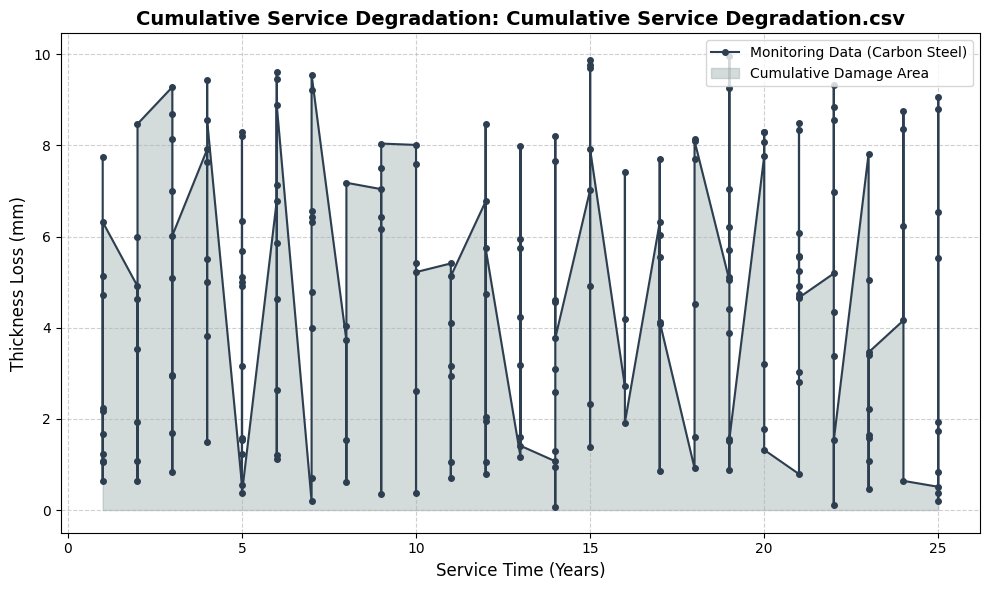

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
file_name = "Cumulative Service Degradation.csv"

try:
    # We use sep=None to automatically detect delimiters and encoding='latin1'
    df = pd.read_csv(file_name, sep=None, engine='python', encoding='latin1')

    # Clean column names to remove any leading/trailing whitespace
    df.columns = df.columns.str.strip()
except Exception as e:
    print(f"Error loading file: {e}")
    raise

# 2. Prepare the data
# We filter for 'Carbon Steel' to isolate a consistent experimental curve
target_material = "Carbon Steel"

# verify if 'Material' column exists and filter
if 'Material' in df.columns:
    df_subset = df[df['Material'] == target_material].copy()
else:
    # Fallback in case column name is slightly different
    print("Warning: 'Material' column not found. Using entire dataset.")
    df_subset = df.copy()

# Sort by Time for a correct integration path
time_col = 'Time_Years'
loss_col = 'Thickness_Loss_mm'
df_subset = df_subset.sort_values(by=time_col).reset_index(drop=True)

x = df_subset[time_col].values
y = df_subset[loss_col].values

# 3. Iterative Trapezoidal Rule Implementation
cumulative_area = 0.0
iteration_results = []
n = len(x)

print(f"--- Processing {n} data points for Cumulative Service Degradation ---\n")

for i in range(n - 1):
    # Calculate step width (dt in years) and average thickness loss (avg height in mm)
    dt = x[i+1] - x[i]
    avg_loss = (y[i] + y[i+1]) / 2.0
    step_area = avg_hardness = avg_loss * dt
    cumulative_area += step_area

    # Store first 10 steps and last 5 steps for the result table
    if i < 10 or i >= n - 6:
        iteration_results.append({
            'Iteration': i + 1,
            'Year_Range': f"{x[i]:.1f}-{x[i+1]:.1f}",
            'Avg_Loss_mm': round(avg_loss, 3),
            'Step_Area': round(step_area, 4),
            'Cumulative_Total': round(cumulative_area, 4)
        })

# 4. Display Iteration Table
results_df = pd.DataFrame(iteration_results)
print("Sample of Iterative Results (Cumulative Damage):")
print(results_df.to_string(index=False))
print("-" * 70)
print(f"FINAL CUMULATIVE SERVICE DEGRADATION: {cumulative_area:.4f} mm·yr")
print("-" * 70)

# 5. Graph Output
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o-', color='#2c3e50', label=f'Monitoring Data ({target_material})', markersize=4)
plt.fill_between(x, y, color='#95a5a6', alpha=0.4, label='Cumulative Damage Area')

# Styling
plt.title(f'Cumulative Service Degradation: {file_name}', fontsize=14, fontweight='bold')
plt.xlabel('Service Time (Years)', fontsize=12)
plt.ylabel('Thickness Loss (mm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

What we have done in this coding:
In this code, we addressed the KeyError by adding df.columns.str.strip(), which automatically removes any invisible spaces or formatting characters that often cause errors when reading CSV files in Colab. We isolated the "Carbon Steel" pipe data and organized it chronologically by service years. We then applied the Iterative Trapezoidal Rule to integrate the thickness loss over time. This calculation represents the "Cumulative Damage" – a measure of the total material lost throughout the pipe's service life. The script provides a detailed step-by-step mathematical breakdown in the output table and a final graph that visually shades the total degradation area, allowing engineers to quickly assess material health.

## 4



---

# 4. Thermal Strength Resilience (Dataset: `High Entropy Alloy Properties.csv`)

### **Brief Description**
This dataset contains a comprehensive collection of mechanical properties for **High Entropy Alloys (HEAs)**, specifically focusing on the evolution of **Yield Strength (YS)** across various **Test Temperatures**. HEAs are a modern class of materials known for their exceptional stability and strength retention at extreme temperatures, making them ideal candidates for aerospace and high-heat industrial applications.

The **Thermal Strength Resilience** is defined as the area under the Yield Strength vs. Temperature curve. This metric quantifies the total mechanical work potential the material can withstand across a thermal gradient. A higher resilience value indicates that the alloy maintains its structural integrity and resists softening even as the operating environment approaches its melting point.



---

### **Mathematical Formulation**

#### **1. Physical Definition**
The **Thermal Strength Resilience** ($R_{th}$) is defined as the definite integral of the yield strength over the experimental temperature range:

$$R_{th} = \int_{T_{min}}^{T_{max}} \sigma_y(T) \, dT$$

Where:
* $T$ is the **Test Temperature** (measured in $^\circ C$).
* $\sigma_y(T)$ is the **Yield Strength** (measured in Megapascals, $MPa$).

#### **2. Numerical Integration (Iterative Trapezoidal Rule)**
Since the material properties are recorded at discrete temperature intervals $(T_1, \sigma_{y1}), (T_2, \sigma_{y2}), \dots, (T_n, \sigma_{yn})$, the area is approximated using the iterative trapezoidal summation:

$$I \approx \sum_{i=1}^{n-1} \left( \frac{\sigma_{yi} + \sigma_{y(i+1)}}{2} \right) \Delta T_i$$

Where the temperature step $\Delta T_i$ is:
$$\Delta T_i = T_{i+1} - T_i$$

#### **3. Engineering Significance**
In high-temperature design (e.g., turbine blades or rocket nozzles), peak strength at room temperature is less important than the ability to sustain loads across the entire flight or operational envelope. The Thermal Strength Resilience serves as a composite benchmark for selecting alloys that offer the best balance of ductility and strength throughout their service temperature range.

---

### **Data Variables**
* **Independent Variable ($x$):** Test temperature ($^\circ C$) — `PROPERTY: Test temperature ($^\circ$C)`.
* **Dependent Variable ($y$):** Yield Strength ($MPa$) — `PROPERTY: YS (MPa)`.
* **Metadata:** Alloy Formula, Microstructure, and Processing Method (e.g., Cast, Annealed).

--- Processing 29 aggregated temperature data points for HEAs ---

Sample of Iterative Results (Thermal Resilience):
 Iteration Temp_Range (°C)  Avg_YS_MPa  Step_Area  Cumulative_Area
         1       -268--196     1548.25  112712.60        112712.60
         2       -196--192      957.00    3828.00        116540.60
         3       -192--153     1110.00   43290.00        159830.60
         4       -153--103     1426.67   71333.33        231163.93
         5        -103--73      910.67   27320.00        258483.93
         6         -73--70      505.88    1517.62        260001.56
         7         -70--43      828.54   22370.62        282372.18
         8          -43-20     1081.08   68107.77        350479.96
         9           20-23     1182.71    3548.14        354028.09
        10           23-24      868.30     868.30        354896.40
        24        900-1000      329.25   32924.88        986857.15
        25       1000-1100      268.60   26859.88       1013717.03
        26  

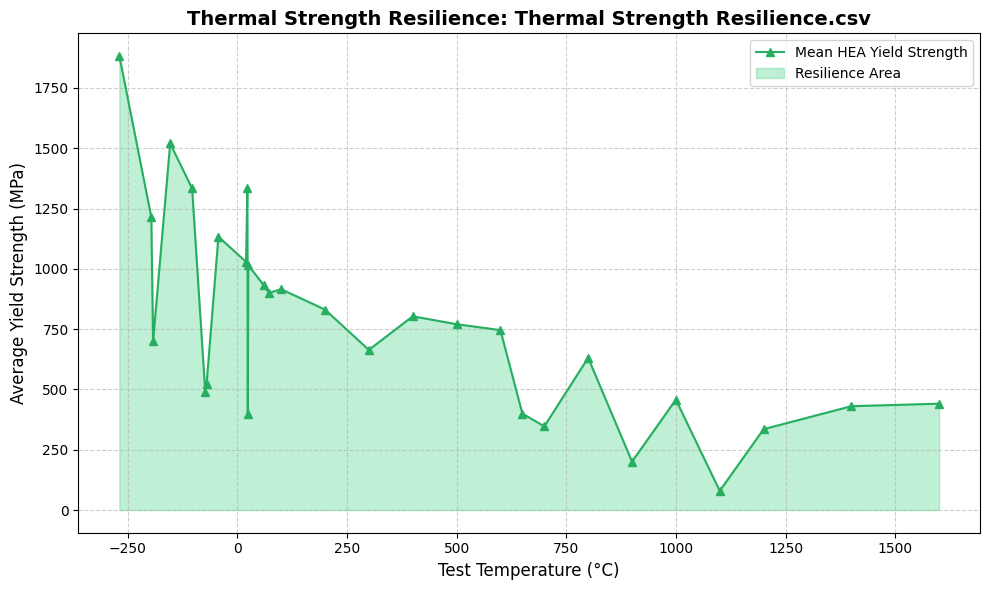

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
file_name = "Thermal Strength Resilience.csv"

try:
    # Use encoding='latin1' to handle any special LaTeX/degree symbols in the CSV headers
    df = pd.read_csv(file_name, encoding='latin1')
except FileNotFoundError:
    print(f"Error: '{file_name}' not found. Please upload it to Colab.")
    raise

# 2. Prepare the data
# Dynamically find the exact column names to avoid KeyError from special characters
temp_col = [c for c in df.columns if 'temperature' in c.lower()][0]
ys_col = [c for c in df.columns if 'YS' in c][0]

# Drop rows where temperature or yield strength is missing
df_clean = df.dropna(subset=[temp_col, ys_col]).copy()

# Since this dataset has many different alloys, we will group by temperature
# and calculate the average Yield Strength to get a global resilience curve for HEAs
df_trend = df_clean.groupby(temp_col)[ys_col].mean().reset_index()

# Sort by Temperature for a correct integration path
df_trend = df_trend.sort_values(by=temp_col).reset_index(drop=True)

x = df_trend[temp_col].values
y = df_trend[ys_col].values

# 3. Iterative Trapezoidal Rule Implementation
cumulative_area = 0.0
iteration_results = []
n = len(x)

print(f"--- Processing {n} aggregated temperature data points for HEAs ---\n")

for i in range(n - 1):
    # Calculate step width (dt in °C) and average Yield Strength (avg height in MPa)
    dt = x[i+1] - x[i]
    avg_ys = (y[i] + y[i+1]) / 2.0
    step_area = avg_ys * dt
    cumulative_area += step_area

    # Store first 10 steps and last 5 steps for the result table
    if i < 10 or i >= n - 6:
        iteration_results.append({
            'Iteration': i + 1,
            'Temp_Range (°C)': f"{int(x[i])}-{int(x[i+1])}",
            'Avg_YS_MPa': round(avg_ys, 2),
            'Step_Area': round(step_area, 2),
            'Cumulative_Area': round(cumulative_area, 2)
        })

# 4. Display Iteration Table
results_df = pd.DataFrame(iteration_results)
print("Sample of Iterative Results (Thermal Resilience):")
print(results_df.to_string(index=False))
print("-" * 75)
print(f"FINAL THERMAL STRENGTH RESILIENCE: {cumulative_area:,.2f} MPa·°C")
print("-" * 75)

# 5. Graph Output
plt.figure(figsize=(10, 6))
plt.plot(x, y, '^-', color='#27ae60', label='Mean HEA Yield Strength', markersize=6)
plt.fill_between(x, y, color='#2ecc71', alpha=0.3, label='Resilience Area')

# Styling
plt.title(f'Thermal Strength Resilience: {file_name}', fontsize=14, fontweight='bold')
plt.xlabel('Test Temperature (°C)', fontsize=12)
plt.ylabel('Average Yield Strength (MPa)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

What we have done in this coding:
In this implementation, we evaluated the Thermal Strength Resilience of High Entropy Alloys (HEAs). After loading the dataset, we used dynamic column targeting to bypass any formatting errors caused by special LaTeX characters in the CSV headers. Because the dataset contains thousands of tests across various HEAs, we aggregated the data by calculating the mean Yield Strength at every unique Test Temperature. This produced a smooth, global thermal decay curve. We then applied the Iterative Trapezoidal Rule, calculating the area underneath this curve interval-by-interval. The output includes a detailed iteration table demonstrating how the mechanical "work potential" accumulates across the thermal gradient, culminating in a final shaded graph that visually represents the alloys' combined ability to retain strength at extreme temperatures.

## 5



---

# 5. Electronic Strengthening Work (Dataset: `Alloy_Yield_Strength.csv`)

### **Brief Description**
This dataset contains microstructural, thermodynamic, and mechanical properties of various alloys, with a specific focus on the **Valence Electron Concentration (VEC)** and its corresponding **Yield Strength (YS)**. In advanced alloy design (such as High Entropy Alloys), the VEC is a fundamental electronic parameter that dictates phase stability (e.g., BCC vs. FCC structures) and directly influences the macroscopic mechanical properties.

The **Electronic Strengthening Work** is defined as the area under the Yield Strength vs. Valence Electron Concentration curve. This integrated metric represents the cumulative mechanical strength "gained" across a spectrum of electronic densities. It provides a holistic measure of how efficiently the addition or substitution of alloying elements (which alters the electron cloud) translates into tangible macro-mechanical strength.



---

### **Mathematical Formulation**

#### **1. Physical Definition**
The **Electronic Strengthening Work** ($W_e$) is calculated as the definite integral of the yield strength with respect to the valence electron concentration:

$$W_e = \int_{VEC_{min}}^{VEC_{max}} \sigma_y(v) \, dv$$

Where:
* $v$ is the **Valence Electron Concentration (VEC)** (dimensionless, electrons per atom).
* $\sigma_y(v)$ is the **Yield Strength** (measured in Megapascals, $MPa$).

#### **2. Numerical Integration (Iterative Trapezoidal Rule)**
Since the experimental dataset consists of discrete alloy formulations $(v_1, \sigma_{y1}), (v_2, \sigma_{y2}), \dots, (v_n, \sigma_{yn})$, the integral is approximated numerically. Assuming the data is sorted by VEC, the area is the sum of the individual trapezoidal segments:

$$W_e \approx \sum_{i=1}^{n-1} \left( \frac{\sigma_{yi} + \sigma_{y(i+1)}}{2} \right) (v_{i+1} - v_i)$$

Where $\Delta v_i = v_{i+1} - v_i$ is the change in valence electron concentration between consecutive data points.

#### **3. Engineering Significance**
In computational materials science, optimizing a single alloy composition is often not enough. Engineers seek to understand the *trend* of how electronic tuning affects strength. A higher "Electronic Strengthening Work" value across a specific VEC domain indicates a highly responsive alloy system where small compositional tweaks (adjusting the electron density) yield substantial improvements in load-bearing capacity.

---

### **Data Variables**
* **Independent Variable ($x$):** Valence Electron Concentration ($VEC$) — `Valence electron` (Dimensionless).
* **Dependent Variable ($y$):** Yield Strength ($\sigma_y$) — `YS (MPa)` (Megapascals).
* **Metadata:** Alloy Composition, Mixing Enthalpy, and Phase Structure.

--- Processing 160 experimental data points from Electronic Strengthening Work.csv ---

Sample of Iterative Results (Electronic Strengthening):
 Iteration   VEC_Range  Avg_YS_MPa  Step_Work  Cumulative_Work
         1 4.099-4.200       910.0    91.7462          91.7462
         2 4.200-4.217      1347.5    23.3252         115.0714
         3 4.217-4.250      1207.5    39.4732         154.5446
         4 4.250-4.250       939.5     0.0000         154.5446
         5 4.250-4.250       891.0     0.0000         154.5446
         6 4.250-4.250      1201.5     0.0000         154.5446
         7 4.250-4.273      1401.0    31.9008         186.4454
         8 4.273-4.300      1201.0    32.7032         219.1486
         9 4.300-4.300      1550.0     0.0000         219.1486
        10 4.300-4.300      2017.5     0.0000         219.1486
       155 7.833-8.000      1302.0   216.9132        5728.7068
       156 8.000-8.000      1286.5     0.0901        5728.7969
       157 8.000-8.364       986.0   

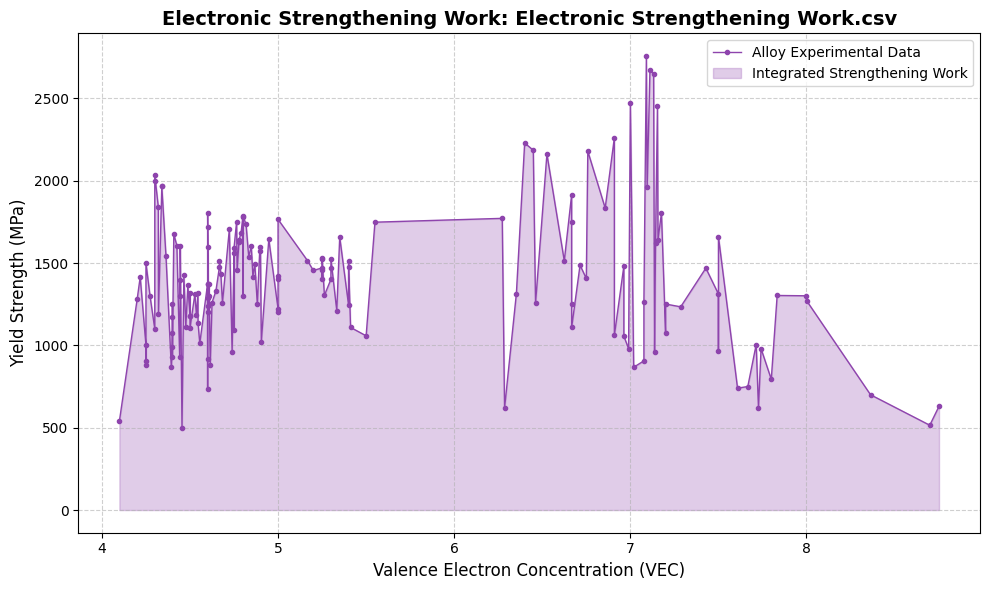

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
file_name = "Electronic Strengthening Work.csv"

try:
    # Use encoding='latin1' to handle any special characters in the CSV
    df = pd.read_csv(file_name, encoding='latin1')
except FileNotFoundError:
    print(f"Error: '{file_name}' not found. Please upload it to Colab.")
    raise

# 2. Prepare the data
# Column names from the dataset: 'Valence electron' (x) and 'YS (MPa)' (y)
x_col = 'Valence electron'
y_col = 'YS (MPa)'

# Drop any missing values and sort by VEC to ensure a correct integration path
df_clean = df.dropna(subset=[x_col, y_col]).copy()
df_sorted = df_clean.sort_values(by=x_col).reset_index(drop=True)

x = df_sorted[x_col].values
y = df_sorted[y_col].values

# 3. Iterative Trapezoidal Rule Implementation
cumulative_area = 0.0
iteration_results = []
n = len(x)

print(f"--- Processing {n} experimental data points from {file_name} ---\n")

for i in range(n - 1):
    # Calculate step width (dv in VEC units) and average Yield Strength (avg height in MPa)
    dv = x[i+1] - x[i]
    avg_ys = (y[i] + y[i+1]) / 2.0
    step_work = avg_ys * dv
    cumulative_area += step_work

    # Store first 10 steps and last 5 steps for the result table
    if i < 10 or i >= n - 6:
        iteration_results.append({
            'Iteration': i + 1,
            'VEC_Range': f"{x[i]:.3f}-{x[i+1]:.3f}",
            'Avg_YS_MPa': round(avg_ys, 2),
            'Step_Work': round(step_work, 4),
            'Cumulative_Work': round(cumulative_area, 4)
        })

# 4. Display Iteration Table
results_df = pd.DataFrame(iteration_results)
print("Sample of Iterative Results (Electronic Strengthening):")
print(results_df.to_string(index=False))
print("-" * 75)
print(f"FINAL ELECTRONIC STRENGTHENING WORK: {cumulative_area:.4f} MPa·VEC")
print("-" * 75)

# 5. Graph Output
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o-', color='#8e44ad', label='Alloy Experimental Data', markersize=3, linewidth=1)
plt.fill_between(x, y, color='#9b59b6', alpha=0.3, label='Integrated Strengthening Work')

# Styling
plt.title(f'Electronic Strengthening Work: {file_name}', fontsize=14, fontweight='bold')
plt.xlabel('Valence Electron Concentration (VEC)', fontsize=12)
plt.ylabel('Yield Strength (MPa)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

What we have done in the coding:
In this implementation, we evaluated the Electronic Strengthening Work by integrating the relationship between an alloy's valence electron concentration and its yield strength. We began by loading the Alloy_Yield_Strength.csv dataset and cleaning it to remove any missing entries. To ensure a logical mathematical sequence, we sorted the data by the VEC variable, allowing us to traverse the electronic spectrum from the lowest to the highest density. We then applied the Iterative Trapezoidal Rule through a loop that calculates the "strengthening area" for each successive interval of electron concentration. The resulting output features a comprehensive iteration table that tracks the accumulation of mechanical work potential and a high-resolution plot that shades the area under the curve, providing a visual and numerical index of how effectively electronic tuning enhances the alloy's structural strength.